# Variational Filtering with a Learned Gain

See Chapter 7, Section 7.2: Variational Formulation Of Filtering; Chapter 9, Section 9.2.1: Learning The Gain In 3DVar; Chapter 9, Section 9.2.2: Learning The Gain In EnKF.

## Problem setting

This demo uses a reduced Lorenz-96 filtering problem. The state is $v\in\mathbb{R}^d$ and evolves according to the cyclic ODE
$$
\frac{dv_k}{dt}=(v_{k+1}-v_{k-2})v_{k-1}-v_k+F,
\qquad k=1,\ldots,d,
$$
with cyclic boundary conditions. The standard forcing is $F=8$. The displayed default uses $d=8$ so that a full gain matrix can be learned quickly, but the same equations apply to the standard $d=40$ Lorenz-96 benchmark.

After one RK4 assimilation window, the stochastic discrete-time model is
$$
v_{j+1}=\Psi(v_j)+\xi_j,
\qquad
\xi_j\sim\mathcal{N}(0,\Sigma),
\qquad
\Sigma=\sigma_v^2 I_d.
$$
The default observation operator is full-state observation,
$$
H=I_d,
$$
so
$$
y_{j+1}=Hv_{j+1}+\eta_{j+1}=v_{j+1}+\eta_{j+1},
\qquad
\eta_{j+1}\sim\mathcal{N}(0,\Gamma),
\qquad
\Gamma=\sigma_y^2 I_d.
$$
The goal is to learn a fixed analysis gain $K\in\mathbb{R}^{d\times d}$ that produces accurate filtering means over a sequence of observations.

The truth trajectory in the code is generated from this same stochastic Lorenz-96 model with the displayed values of $d$, $F$, $\sigma_v$, and $\sigma_y$. The learned object is the gain $K$; the physical Lorenz-96 parameters are fixed in this demo.

## Variational filtering objective

Let
$$
\pi_j=\mathbb{P}(v_j\mid y^\dagger_1,\ldots,y^\dagger_j)
$$
be the filtering distribution. The filtering recursion has prediction and analysis steps
$$
\widehat\pi_{j+1}=\mathsf{P}\pi_j,
\qquad
\widehat\pi_{j+1}=\mathbb{P}(v_{j+1}\mid y^\dagger_1,\ldots,y^\dagger_j),
$$
$$
\pi_{j+1}=\mathsf{A}(\widehat\pi_{j+1};y^\dagger_{j+1}).
$$
At each step, approximate $\pi_{j+1}$ by $q_{j+1}$ through the variational objective
$$
\arg\min_qD_{\rm KL}(q\|\pi_{j+1})
=
\arg\min_qD_{\rm KL}(q\|\widehat\pi_{j+1})
-\mathbb{E}_{u\sim q}[\log\mathsf{I}(y^\dagger_{j+1};u)].
$$
We define $q_j(\theta)$ recursively with $\theta=K$ and minimize
$$
\min_\theta\frac{1}{J}\sum_{j=0}^{J}L_j(q_j(\theta)).
$$

For a Gaussian ansatz, the prediction step is
$$
\widehat m_{j+1}=\Psi(m_j),
$$
$$
\widehat C_{j+1}=J_jC_jJ_j^\top+\Sigma,
\qquad
J_j=\text{Jacobian of }\Psi.
$$
The learned-gain analysis step is
$$
m_{j+1}=\widehat m_{j+1}+K(y^\dagger_{j+1}-H\widehat m_{j+1}),
$$
$$
C_{j+1}=(I-KH)\widehat C_{j+1}(I-KH)^\top+K\Gamma K^\top.
$$
Define
$$
\widehat\pi_{j+1}=\mathcal{N}(\widehat m_{j+1},\widehat C_{j+1}),
\qquad
q_{j+1}(K)=\mathcal{N}(m_{j+1}(K),C_{j+1}(K)).
$$
The learning objective is
$$
L(K)=\frac{1}{J}\sum_{j=1}^{J}
D_{\rm KL}(q_{j+1}(K)\|\widehat\pi_{j+1})
-\mathbb{E}_{u\sim q_{j+1}(K)}[\log\mathsf{I}(u;y_{j+1})].
$$
The state-estimation diagnostic is
$$
\operatorname{RMSE}=
\sqrt{\frac{1}{Jd}\sum_{j=1}^{J}\|m_j-v_j^\dagger\|_2^2}.
$$


**Parameter exploration.**

- Increase `state_dim` to make the gain matrix richer and the optimization harder.
- Increase `training_iterations` until the variational objective plateaus; too few iterations usually leave the learned gain close to the initialization.
- Increase `sigma_y` to make the observation term less dominant; the learned gain should become more conservative.
- Toggle `force_retrain` only when you want to ignore an existing checkpoint and rerun gain learning.

**Recommended test combinations.** Keep unspecified controls at their displayed defaults.

| `state_dim` | `training_iterations` | `sigma_y` | Purpose |
|---:|---:|---:|---|
| 6 | 150 | 1.0 | Fast check of the learned-gain mechanism. |
| 8 | 220 | 1.0 | Balanced default with a visible full gain matrix. |
| 12 | 350 | 1.5 | Harder, noisier case with a more conservative gain. |


Loaded checkpoint: checkpoints/variational_filtering_learned_gain/b22370e13c8c.pt
Baseline fixed-gain RMSE: 1.467, objective: 16.504
Learned gain RMSE:        0.550, objective: 7.251


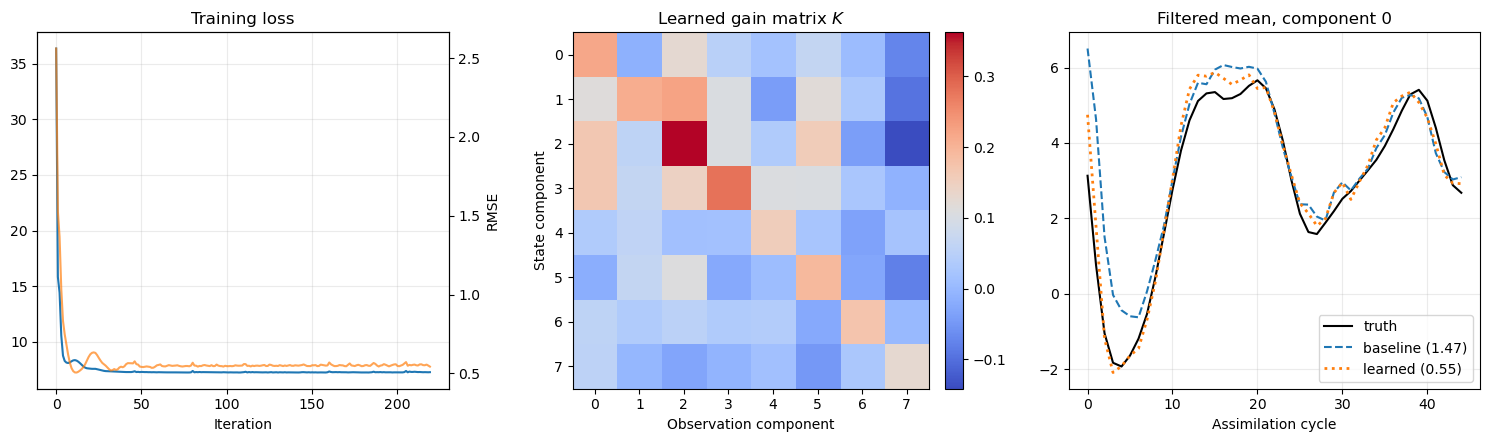

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

DEFAULTS = {
    "state_dim": 8,
    "forcing": 8.0,
    "dt": 0.01,
    "rk4_steps_per_cycle": 5,
    "cycles": 45,
    "sigma_v": 0.03,
    "sigma_y": 1.0,
    "training_iterations": 220,
    "learning_rate": 0.03,
    "gain_penalty": 1e-3,
    "random_seed": 33,
    "force_retrain": False,
}

use_default = False #@param {type:"boolean"}
state_dim = 8 #@param {type:"slider", min:4, max:16, step:2}
cycles = 45 #@param {type:"slider", min:20, max:80, step:5}
training_iterations = 220 #@param {type:"slider", min:50, max:500, step:25}
learning_rate = 0.03 #@param {type:"slider", min:0.005, max:0.08, step:0.005}
sigma_y = 1.0 #@param {type:"slider", min:0.5, max:2.0, step:0.25}
force_retrain = False #@param {type:"boolean"}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "state_dim": int(state_dim),
        "cycles": int(cycles),
        "training_iterations": int(training_iterations),
        "learning_rate": float(learning_rate),
        "sigma_y": float(sigma_y),
        "force_retrain": bool(force_retrain),
    })


def checkpoint_path(params):
    cache_params = {k: v for k, v in params.items() if k != "force_retrain"}
    key = hashlib.sha256(json.dumps(cache_params, sort_keys=True).encode()).hexdigest()[:12]
    path = Path("checkpoints") / "variational_filtering_learned_gain"
    path.mkdir(parents=True, exist_ok=True)
    return path / f"{key}.pt"


torch.manual_seed(params["random_seed"])
torch.set_default_dtype(torch.float64)


def l96_rhs_torch(v, forcing):
    return (torch.roll(v, -1) - torch.roll(v, 2)) * torch.roll(v, 1) - v + forcing


def rk4_window_torch(v, params):
    x = v
    dt = params["dt"]
    for _ in range(params["rk4_steps_per_cycle"]):
        k1 = l96_rhs_torch(x, params["forcing"])
        k2 = l96_rhs_torch(x + 0.5 * dt * k1, params["forcing"])
        k3 = l96_rhs_torch(x + 0.5 * dt * k2, params["forcing"])
        k4 = l96_rhs_torch(x + dt * k3, params["forcing"])
        x = x + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    return x


def make_data(params):
    rng = np.random.default_rng(params["random_seed"])
    n = params["state_dim"]
    x = params["forcing"] * np.ones(n)
    x[0] += 0.01
    x += 0.03 * rng.normal(size=n)
    xt = torch.tensor(x)
    for _ in range(200):
        xt = rk4_window_torch(xt, params).detach()
    truth = []
    obs = []
    for _ in range(params["cycles"]):
        xt = rk4_window_torch(xt, params).detach()
        xt = xt + params["sigma_v"] * torch.randn(n)
        truth.append(xt.clone())
        obs.append(xt + params["sigma_y"] * torch.randn(n))
    return torch.stack(truth), torch.stack(obs)


truth, obs = make_data(params)


def gaussian_kl(m1, C1, m2, C2):
    n = m1.numel()
    jitter = 1e-5 * torch.eye(n)
    C1 = C1 + jitter
    C2 = C2 + jitter
    chol2 = torch.linalg.cholesky(C2)
    sol = torch.cholesky_solve(C1, chol2)
    diff = (m2 - m1).unsqueeze(1)
    quad = (diff.T @ torch.cholesky_solve(diff, chol2)).squeeze()
    logdet = torch.logdet(C2) - torch.logdet(C1)
    return 0.5 * (logdet - n + torch.trace(sol) + quad)


def filter_with_gain(K, obs, params, return_cov=False):
    n = params["state_dim"]
    I = torch.eye(n)
    Q = params["sigma_v"] ** 2 * I
    R = params["sigma_y"] ** 2 * I
    m = params["forcing"] * torch.ones(n)
    m[0] += 0.01
    C = torch.eye(n)
    means, covs = [], []
    vi_loss = torch.tensor(0.0)
    for y in obs:
        m_pred = rk4_window_torch(m, params)
        C_pred = 1.02 * C + Q
        innovation = y - m_pred
        m = m_pred + K @ innovation
        I_KH = I - K
        C = I_KH @ C_pred @ I_KH.T + K @ R @ K.T
        C = 0.5 * (C + C.T) + 1e-5 * I
        q_to_pred = gaussian_kl(m, C, m_pred, C_pred)
        expected_nll = 0.5 * (((y - m) ** 2).sum() + torch.trace(C)) / params["sigma_y"] ** 2
        vi_loss = vi_loss + q_to_pred + expected_nll
        means.append(m)
        covs.append(C)
    means = torch.stack(means)
    if return_cov:
        return means, torch.stack(covs), vi_loss / len(obs)
    return means, vi_loss / len(obs)


def train_gain(params):
    n = params["state_dim"]
    raw_K = torch.nn.Parameter(0.15 * torch.eye(n) + 0.01 * torch.randn(n, n))
    optimizer = torch.optim.Adam([raw_K], lr=params["learning_rate"])
    losses = []
    rmses = []
    for _ in range(params["training_iterations"]):
        optimizer.zero_grad()
        K = torch.tanh(raw_K)
        means, loss = filter_with_gain(K, obs, params)
        reg = params["gain_penalty"] * torch.mean(K**2)
        total = loss + reg
        total.backward()
        torch.nn.utils.clip_grad_norm_([raw_K], 10.0)
        optimizer.step()
        with torch.no_grad():
            rmse = torch.sqrt(torch.mean((means - truth) ** 2))
            losses.append(float(loss.detach()))
            rmses.append(float(rmse))
    return {"K": torch.tanh(raw_K).detach(), "losses": losses, "rmses": rmses}


ckpt = checkpoint_path(params)
if ckpt.exists() and not params["force_retrain"]:
    payload = torch.load(ckpt, map_location="cpu", weights_only=False)
    print(f"Loaded checkpoint: {ckpt}")
else:
    payload = train_gain(params)
    torch.save(payload, ckpt)
    print(f"Saved checkpoint: {ckpt}")

K_learned = payload["K"]
baseline_K = 0.25 * torch.eye(params["state_dim"])
learned_means, learned_covs, learned_vi = filter_with_gain(K_learned, obs, params, True)
base_means, base_covs, base_vi = filter_with_gain(baseline_K, obs, params, True)
rmse_learned = float(torch.sqrt(torch.mean((learned_means - truth) ** 2)))
rmse_base = float(torch.sqrt(torch.mean((base_means - truth) ** 2)))
print(f"Baseline fixed-gain RMSE: {rmse_base:.3f}, objective: {float(base_vi):.3f}")
print(f"Learned gain RMSE:        {rmse_learned:.3f}, objective: {float(learned_vi):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(payload["losses"], label="variational objective")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Iteration")
axes[0].grid(alpha=0.25)
ax2 = axes[0].twinx()
ax2.plot(payload["rmses"], color="C1", alpha=0.7, label="RMSE")
ax2.set_ylabel("RMSE")

im = axes[1].imshow(K_learned.numpy(), cmap="coolwarm")
axes[1].set_title("Learned gain matrix $K$")
axes[1].set_xlabel("Observation component")
axes[1].set_ylabel("State component")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

dim = 0
axes[2].plot(truth[:, dim].numpy(), "k-", lw=1.5, label="truth")
axes[2].plot(base_means[:, dim].detach().numpy(), "C0--", label=f"baseline ({rmse_base:.2f})")
axes[2].plot(learned_means[:, dim].detach().numpy(), "C1:", lw=2, label=f"learned ({rmse_learned:.2f})")
axes[2].set_title("Filtered mean, component 0")
axes[2].set_xlabel("Assimilation cycle")
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()
